In [1]:
import numpy as np
from dataclasses import dataclass
from typing import List, Optional, Tuple

@dataclass
class LinearSystem:
    """Finite-horizon linear system x_{t+1} = A x_t + B u_t + w_t."""
    A: np.ndarray
    B: np.ndarray
    Sigma_w: np.ndarray
    H: int
    Sigma_x0: Optional[np.ndarray] = None


def symmetrize(M: np.ndarray) -> np.ndarray:
    """Project a matrix onto the symmetric matrices."""
    return 0.5 * (M + M.T)


def is_psd(M: np.ndarray, tol: float = 1e-9) -> bool:
    """Numerically test positive semidefiniteness."""
    eigs = np.linalg.eigvalsh(symmetrize(M))
    return np.min(eigs) >= -tol


def block_partition(
    M: np.ndarray, n: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Partition a stage-cost matrix M into xx/xu/ux/uu blocks,
    where the state has dimension n and the input has dimension m = M.shape[0] - n.
    """
    xx = M[:n, :n]
    xu = M[:n, n:]
    ux = M[n:, :n]
    uu = M[n:, n:]
    return xx, xu, ux, uu


def generalized_lqr_riccati(
    system: LinearSystem,
    M_tilde: np.ndarray,
    psd_tol: float = 1e-9,
) -> Tuple[bool, Optional[List[np.ndarray]], Optional[List[np.ndarray]], Optional[List[np.ndarray]]]:
    """
    Solve the finite-horizon generalized LQR problem with constant stage-cost
    matrix M_tilde = [[M_xx, M_xu], [M_ux, M_uu]].

    Returns
    -------
    well_posed : bool
        True if S_t is PSD for all t.
    K_list : list[np.ndarray] or None
        Feedback gains u_t = -K_t x_t if well posed.
    P_list : list[np.ndarray] or None
        Riccati matrices.
    S_list : list[np.ndarray] or None
        S_t matrices in the recursion.
    """
    A, B, H = system.A, system.B, system.H
    n = A.shape[0]
    xx, xu, ux, uu = block_partition(M_tilde, n)

    P_list = [np.zeros((n, n)) for _ in range(H + 1)]  # terminal P_H = 0
    K_list = [np.zeros((B.shape[1], n)) for _ in range(H)]
    S_list = [np.zeros((B.shape[1], B.shape[1])) for _ in range(H)]

    for t in reversed(range(H)):
        P_next = P_list[t + 1]
        S_t = symmetrize(uu + B.T @ P_next @ B)
        S_list[t] = S_t

        if not is_psd(S_t, tol=psd_tol):
            return False, None, None, None

        middle = ux + B.T @ P_next @ A
        S_inv = np.linalg.inv(S_t)  # robust near-singular inverse
        K_t = S_inv @ middle
        K_list[t] = K_t

        P_t = xx + A.T @ P_next @ A - middle.T @ K_t
        P_list[t] = symmetrize(P_t)

    return True, K_list, P_list, S_list


def induced_covariance(
    system: LinearSystem,
    K_list: List[np.ndarray],
) -> Tuple[np.ndarray, List[np.ndarray], List[np.ndarray], List[np.ndarray]]:
    """
    Propagate closed-loop covariances under u_t = -K_t x_t and return

        Sigma_S^pi = E[sum_t z_t z_t^T]

    together with per-time covariances Sigma_x,t, Sigma_u,t, Sigma_xu,t.
    """
    A, B, Sigma_w, H = system.A, system.B, system.Sigma_w, system.H
    n = A.shape[0]
    m = B.shape[1]
    Sigma_x = np.zeros((n, n)) if system.Sigma_x0 is None else system.Sigma_x0.copy()

    Sigma_S = np.zeros((n + m, n + m))
    Sigma_x_list, Sigma_u_list, Sigma_xu_list = [], [], []

    for t in range(H):
        K_t = K_list[t]
        Sigma_u = K_t @ Sigma_x @ K_t.T
        Sigma_xu = -Sigma_x @ K_t.T

        Sigma_z = np.block([
            [Sigma_x, Sigma_xu],
            [Sigma_xu.T, Sigma_u],
        ])
        Sigma_S += Sigma_z

        Sigma_x_list.append(Sigma_x.copy())
        Sigma_u_list.append(Sigma_u.copy())
        Sigma_xu_list.append(Sigma_xu.copy())

        A_cl = A - B @ K_t
        Sigma_x = symmetrize(A_cl @ Sigma_x @ A_cl.T + Sigma_w)

    return Sigma_S, Sigma_x_list, Sigma_u_list, Sigma_xu_list


def objective_value(Sigma_S: np.ndarray, W1: np.ndarray) -> float:
    """f(Sigma) = Tr(W1 Sigma^{-1})."""
    Sigma_inv = np.linalg.pinv(symmetrize(Sigma_S))
    return float(np.trace(W1 @ Sigma_inv))


def gradient_objective(Sigma_S: np.ndarray, W1: np.ndarray) -> np.ndarray:
    """∇f(Sigma) = -Sigma^{-1} W1 Sigma^{-1}."""
    #Sigma_inv = np.linalg.pinv(symmetrize(Sigma_S))
    Sigma_inv = np.linalg.inv(symmetrize(Sigma_S))
    return -Sigma_inv @ W1 @ Sigma_inv


def solve_fixed_lambda_subproblem(
    system: LinearSystem,
    M_i: np.ndarray,
    W2: np.ndarray,
    lam: float,
    psd_tol: float = 1e-9,
) -> Tuple[bool, Optional[List[np.ndarray]], Optional[np.ndarray]]:
    """
    Solve the fixed-λ generalized LQR subproblem with stage-cost matrix

        M_tilde(λ) = M_i + λ W2.

    Returns whether it is well posed, the policy gains K_t, and Sigma_S^pi.
    """
    M_tilde = symmetrize(M_i + lam * W2)
    well_posed, K_list, _, _ = generalized_lqr_riccati(system, M_tilde, psd_tol=psd_tol)
    if not well_posed:
        return False, None, None

    Sigma_S, _, _, _ = induced_covariance(system, K_list)
    return True, K_list, Sigma_S


def bisection_lambda(
    system: LinearSystem,
    beta: float,
    eps: float,
    lambda_min: float,
    lambda_max: float,
    J_max: int,
    M_i: np.ndarray,
    W2: np.ndarray,
    psd_tol: float = 1e-10,
    max_expand_iters: Optional[int] = None,
) -> Tuple[float, List[np.ndarray], np.ndarray]:
    """
    Budget-constrained generalized-LQR solve by two-stage bisection over λ.

    Stage 1:
        Find the smallest admissible λ in [lambda_min, lambda_max] that yields
        a well-posed generalized LQR problem.

    Stage 2:
        Restrict to feasible λ and bisect until the budget
            Tr(W2 Sigma_S^pi) <= beta
        is satisfied within tolerance.

    Parameters
    ----------
    max_expand_iters :
        Maximum number of times the upper λ bound is expanded to find a
        budget-feasible value. If None, defaults to system.H.

    Notes
    -----
    The implementation assumes that increasing λ makes the problem more regularized
    and eventually budget-feasible.
    """
    if max_expand_iters is None:
        max_expand_iters = system.H

    # Stage 1: smallest well-posed λ
    lo_wp, hi_wp = lambda_min, lambda_max
    for _ in range(J_max):
        if hi_wp - lo_wp <= eps:
            break
        lam = 0.5 * (lo_wp + hi_wp)
        M_tilde = symmetrize(M_i + lam * W2)
        well_posed, _, _, _ = generalized_lqr_riccati(system, M_tilde, psd_tol=psd_tol)
        if well_posed:
            hi_wp = lam
        else:
            lo_wp = lam

    lambda_min_feasible = hi_wp

    # Expand the upper bound until budget-feasible
    hi = lambda_max
    K_list = None
    Sigma_S = None
    for _ in range(max_expand_iters):
        ok, K_list, Sigma_S = solve_fixed_lambda_subproblem(
            system=system,
            M_i=M_i,
            W2=W2,
            lam=hi,
            psd_tol=psd_tol,
        )
        if ok and Sigma_S is not None and float(np.trace(W2 @ Sigma_S)) <= beta:
            break
        hi = max(2.0 * hi, hi + 1.0)
    else:
        raise RuntimeError("Could not find a budget-feasible upper bound for lambda.")

    # Stage 2: budget bisection
    lo = lambda_min_feasible
    best_lam = hi
    best_K = K_list
    best_Sigma = Sigma_S

    for _ in range(J_max):
        if hi - lo <= eps:
            break

        lam = 0.5 * (lo + hi)
        ok, K_list, Sigma_S = solve_fixed_lambda_subproblem(
            system=system,
            M_i=M_i,
            W2=W2,
            lam=lam,
            psd_tol=psd_tol,
        )
        if not ok:
            lo = lam
            continue

        budget_val = float(np.trace(W2 @ Sigma_S))
        if budget_val > beta:
            lo = lam
        else:
            hi = lam
            best_lam, best_K, best_Sigma = lam, K_list, Sigma_S

    if best_K is None or best_Sigma is None:
        raise RuntimeError("Bisection failed to produce a feasible policy.")

    return best_lam, best_K, best_Sigma


def frank_wolfe_input_design(
    system: LinearSystem,
    Sigma0: np.ndarray,
    W1: np.ndarray,
    W2: np.ndarray,
    beta: float,
    eps: float,
    lambda_max: float,
    J_max: int,
    I_max: int,
    max_expand_iters: Optional[int] = None,
):
    """
    Frank–Wolfe applied to

        min_pi Tr(W1 (Sigma_S^pi)^{-1})
        s.t.   Tr(W2 Sigma_S^pi) <= beta.

    Returns
    -------
    Sigma_hist : list[np.ndarray]
        Frank–Wolfe iterates Sigma_S^{(i)}.
    obj_hist : list[float]
        Objective values f(Sigma_S^{(i)}).
    policy_hist : list[list[np.ndarray]]
        Time-varying gains K_t for the policy returned by the LMO at each iteration.
    lambda_hist : list[float]
        Chosen λ values from the bisection solve.
    """
    Sigma_hist = [symmetrize(Sigma0)]
    obj_hist = [objective_value(Sigma_hist[0], W1)]
    policy_hist = []
    lambda_hist = []

    for i in range(I_max):
        Sigma_i = Sigma_hist[-1]

        # Compute the Frank–Wolfe gradient
        M_i = gradient_objective(Sigma_i, W1)

        # Linear minimization oracle via bisection over λ
        lam_star, policy_i, Sigma_pi = bisection_lambda(
            system=system,
            beta=beta,
            eps=eps,
            lambda_min=0.0,
            lambda_max=lambda_max,
            J_max=J_max,
            M_i=M_i,
            W2=W2,
            max_expand_iters=max_expand_iters,
        )

        fw_gap = abs(float(np.trace(M_i @ (Sigma_i - Sigma_pi))))
        policy_hist.append(policy_i)
        lambda_hist.append(lam_star)

        # Stopping criterion
        if fw_gap <= eps:
            break

        # Fixed step size
        alpha_i = 2.0 / (i + 2.0)

        # Frank–Wolfe update
        Sigma_next = symmetrize((1.0 - alpha_i) * Sigma_i + alpha_i * Sigma_pi)

        Sigma_hist.append(Sigma_next)
        obj_hist.append(objective_value(Sigma_next, W1))

    return Sigma_hist, obj_hist, policy_hist, lambda_hist

# Main

Initial feasible budget use: 16.450845
beta=20.00 | iterations=51 | initial obj=12.715837 | final obj=0.437563 | final budget use=20.000000
beta=50.00 | iterations=51 | initial obj=12.715837 | final obj=0.157500 | final budget use=49.999827
beta=100.00 | iterations=51 | initial obj=12.715837 | final obj=0.079952 | final budget use=99.993414
beta=200.00 | iterations=51 | initial obj=12.715837 | final obj=0.040562 | final budget use=199.870480
beta=500.00 | iterations=51 | initial obj=12.715837 | final obj=0.016673 | final budget use=491.655492
beta=1000.00 | iterations=51 | initial obj=12.715837 | final obj=0.009618 | final budget use=855.851406


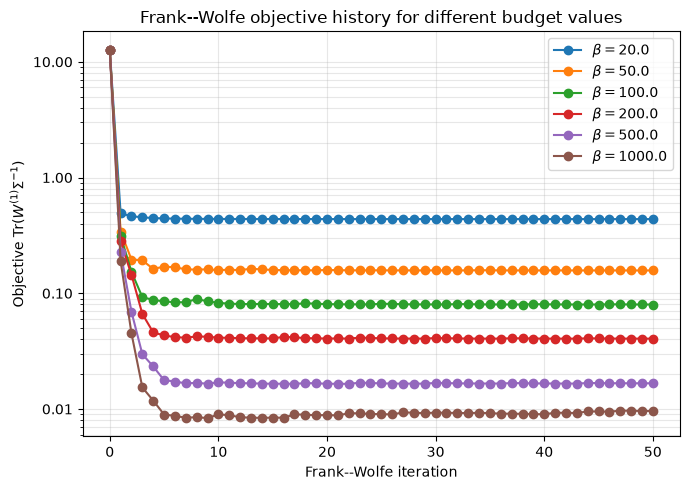

In [2]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import tikzplotlib

    # User-chosen problem data
    H = 100
    A = np.array([
        [1.0, 0.15],
        [0.0, 0.92],
    ])
    B = np.array([
        [0.1],
        [0.4],
    ])
    Sigma_w = 0.02 * np.eye(2)

    system = LinearSystem(
        A=A,
        B=B,
        Sigma_w=Sigma_w,
        H=H,
    )

    n, m = A.shape[0], B.shape[1]

    # Weight matrices in the objective and budget constraint
    W1 = np.diag([2.0, 1.0, 0.5])
    W2 = np.diag([1.0, 1.0, 0.3])

    # Construct an initial feasible covariance
    M_init = np.zeros((n + m, n + m))
    # Maybe initial prior should be selected differently
    ok, _, Sigma0 = solve_fixed_lambda_subproblem(
        system=system,
        M_i=M_init,
        W2=W2,
        lam=1.0,
    )
    if not ok or Sigma0 is None:
        raise RuntimeError("Failed to construct a feasible initial covariance.")

    initial_budget_use = float(np.trace(W2 @ Sigma0))
    print(f"Initial feasible budget use: {initial_budget_use:.6f}")

    # Grid of budget values
    beta_grid = [20.0, 50.0, 100.0,200.0, 500.0, 1000.0]

    # Frank–Wolfe / bisection parameters
    eps = 1e-10
    lambda_max = 1000
    J_max = 5000
    I_max = 50

    # Run Frank–Wolfe for each beta
    results = {}

    for beta in beta_grid:
        Sigma_hist, obj_hist, policy_hist, lambda_hist = frank_wolfe_input_design(
            system=system,
            Sigma0=Sigma0,
            W1=W1,
            W2=W2,
            beta=beta,
            eps=eps,
            lambda_max=lambda_max,
            J_max=J_max,
            I_max=I_max,
            max_expand_iters=H,
        )

        results[beta] = {
            "Sigma_hist": Sigma_hist,
            "obj_hist": obj_hist,
            "policy_hist": policy_hist,
            "lambda_hist": lambda_hist,
        }

        print(
            f"beta={beta:.2f} | "
            f"iterations={len(obj_hist)} | "
            f"initial obj={obj_hist[0]:.6f} | "
            f"final obj={obj_hist[-1]:.6f} | "
            f"final budget use={np.trace(W2 @ Sigma_hist[-1]):.6f}"
        )

    # Plot objective histories for all beta values on a log scale
    plt.figure(figsize=(7, 5))
    for beta in beta_grid:
        obj_hist = results[beta]["obj_hist"]
        iters = np.arange(len(obj_hist))
        plt.semilogy(iters, obj_hist, marker="o", label=fr"$\beta={beta}$")

    plt.xlabel("Frank--Wolfe iteration")
    plt.ylabel(r"Objective $\mathrm{Tr}(W^{(1)} \Sigma^{-1})$")
    plt.title("Frank--Wolfe objective history for different budget values")
    plt.grid(True, which="both", alpha=0.3)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    plt.legend(loc="upper right")
    plt.tight_layout()


    # Save as TikZ/PGFPlots
    tikzplotlib.save("fw_objective_vs_beta.tex")

    plt.show()